In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('indian_tech_jobs_2026.csv')

In [4]:
df.head()

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7.0,10.0,...,2025-06-10,Undisclosed,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,0.0,21.0,False,False
1,2,Data Scientist,Caterpillar Inc,4.1,Bengaluru,Bangalore,Data Scientist,4-8 Yrs,4.0,8.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21.0,False,False
2,3,Analytics Data Scientist,Foreign IT Consulting MNC,3.6,"Hyderabad, Chennai, Bengaluru",Bangalore,Data Scientist,4-9 Yrs,4.0,9.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Business Intelligence,0.0,21.0,False,False
3,4,Data Scientist,Fortune 500 IT Services Company,3.6,"Mumbai, Bengaluru",Bangalore,Data Scientist,10-14 Yrs,0.0,0.0,...,2025-06-10,Undisclosed,Fresher,False,Mumbai,Data Science,0.0,21.0,True,False
4,5,Sr. Artificial Intelligence Engineer,Fortune 500 Product-based MNC,3.6,"Pune, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5.0,10.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),True,Pune,Data Science,0.0,21.0,False,False


In [5]:
df.shape

(8791, 32)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isna().sum()

,0
job_id,0
job_title,0
company_name,0
company_rating,0
location,0
scraped_city,0
role_category,0
experience_raw,0
experience_min_yrs,0
experience_max_yrs,0


In [8]:
df.fillna(df.median(numeric_only=True), inplace=True)
for col in df.select_dtypes(include='object').columns:
  df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_1811/2734919179.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_1811/2734919179.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col].fillna(df[col].mode()[0], inplace=True)


In [9]:
print(df.isna().sum().sum())

0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8791 entries, 0 to 8790
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               8791 non-null   int64  
 1   job_title            8791 non-null   object 
 2   company_name         8791 non-null   object 
 3   company_rating       8791 non-null   float64
 4   location             8791 non-null   object 
 5   scraped_city         8791 non-null   object 
 6   role_category        8791 non-null   object 
 7   experience_raw       8791 non-null   object 
 8   experience_min_yrs   8791 non-null   float64
 9   experience_max_yrs   8791 non-null   float64
 10  salary_raw           8791 non-null   object 
 11  salary_min_lpa       8791 non-null   float64
 12  salary_max_lpa       8791 non-null   float64
 13  salary_disclosed     8791 non-null   bool   
 14  skills_required      8791 non-null   object 
 15  skills_count         8791 non-null   i

In [11]:
df.dtypes

,0
job_id,int64
job_title,object
company_name,object
company_rating,float64
location,object
scraped_city,object
role_category,object
experience_raw,object
experience_min_yrs,float64
experience_max_yrs,float64


In [12]:
df['job_id'].value_counts()

,count
job_id,
8791,1
1,1
2,1
3,1
4,1
...,...
12,1
11,1
10,1


In [13]:
df['job_id'].nunique()

8791

In [14]:
df.shape

(8791, 32)

In [15]:
df.drop(columns=['job_id'], inplace=True)

In [16]:
df['job_title'].value_counts()

,count
job_title,
Data Scientist,506
Data Engineer,496
Data Analyst,403
Business Analyst,329
Senior Data Engineer,214
...,...
Specialist - Technical Analyst,1
Risk Analyst - NBFC Company,1
Company Secretary cum MIS Analyst,1


In [17]:
df['job_title'].nunique()

4383

In [18]:
job_title_freq = df['job_title'].value_counts()
df['job_title_freq'] = df['job_title'].map(job_title_freq).fillna(0)

In [19]:
df.drop(columns=['job_title'], inplace=True)

In [20]:
df['company_name'].value_counts()

,count
company_name,
Tata Consultancy Services,385
Accenture,210
Leading Client,95
EY,94
Photon,91
...,...
Amudhalakshmi Systems,1
Sysarc Infomatix,1
Botminds,1


In [21]:
company_freq = df["company_name"].value_counts()

df["company_name_freq"] = df["company_name"].map(company_freq).fillna(0)

In [22]:
df.drop(columns=["company_name"], inplace=True)

In [23]:
df['location'].value_counts()

,count
location,
Bengaluru,1056
Gurugram,749
Mumbai,696
Remote,676
Pune,663
...,...
"Delhi, Gurgaon",1
"New Delhi, Lakshadweep, Panaji, Dadra & Nagar Haveli, Nagar, North & Middle Andaman, Daman & Diu, Jammu",1
"Pune, Kolkata, Nagpur, Hyderabad, Mumbai (All Areas)",1


In [24]:
location_freq = df["location"].value_counts()

df["location_freq"] = df["location"].map(location_freq).fillna(0)

In [25]:
df.drop(columns=['location'], inplace=True)

In [26]:
df['scraped_city'].value_counts()

,count
scraped_city,
Bangalore,1480
Mumbai,1280
Pune,1263
Delhi,1247
Chennai,1114
Noida,591
Remote,556
Kolkata,473
Gurgaon,432


In [27]:
df['scraped_city'].nunique()

11

In [28]:
df['role_category'].value_counts()

,count
role_category,
Data Scientist,6455
Data Analyst,2336


In [29]:
df['role_category'].nunique()

2

In [30]:
df['experience_raw'].value_counts()

,count
experience_raw,
5-10 Yrs,1008
3-8 Yrs,473
4-9 Yrs,338
3-5 Yrs,330
5-8 Yrs,327
...,...
4-11 Yrs,1
14-20 Yrs,1
09 Jun - 21 Jun,1


In [31]:
df['experience_raw'].nunique()

176

In [32]:
df["experience_raw"] = (
    df["experience_raw"]
    .str.extract(r"(\d+)")
    .astype(float)
)

In [33]:
df["experience_raw"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8791 entries, 0 to 8790
Series name: experience_raw
Non-Null Count  Dtype  
--------------  -----  
8709 non-null   float64
dtypes: float64(1)
memory usage: 68.8 KB


In [34]:
df['salary_raw'].value_counts()

,count
salary_raw,
Not Disclosed,7734
Unpaid,101
15-30 Lacs PA,68
10-20 Lacs PA,35
20-35 Lacs PA,29
...,...
5.5-13 Lacs PA,1
4.5-8 Lacs PA,1
1.75-2.5 Lacs PA,1


In [35]:
df['salary_raw'].nunique()

280

In [36]:
df["salary_raw"] = (
    df["salary_raw"]
    .str.extract(r"(\d+\.?\d*)")
    .astype(float)
)

In [37]:
df["salary_raw"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8791 entries, 0 to 8790
Series name: salary_raw
Non-Null Count  Dtype  
--------------  -----  
955 non-null    float64
dtypes: float64(1)
memory usage: 68.8 KB


In [38]:
df['primary_city'].value_counts()

,count
primary_city,
Pune,1281
Mumbai,1251
Bangalore,1168
Chennai,1101
Gurgaon,877
...,...
Pune(Hinjewadi Phase 2),1
Pune(Hadapsar),1
Chennai(Mettukuppam),1


In [39]:
df['primary_city'].nunique()

85

In [40]:
primary_city_freq = df["primary_city"].value_counts()

df["primary_city_freq"] = df["primary_city"].map(primary_city_freq).fillna(0)

In [41]:
df.drop(columns=['primary_city'], inplace=True)

In [42]:
df['skill_domain'].value_counts()

,count
skill_domain,
Business Intelligence,3983
AI/ML/DL,2134
Cloud & DevOps,1420
Data Engineering,663
Data Science,591


In [43]:
df['skill_domain'].nunique()

5

In [44]:
df['skills_required'].value_counts()

,count
skills_required,
Not Available,152
"algorithms, python, modeling, data analysis, data analytics, natural language processing, predictive, machine learning",16
"Business Analyst, Business analysis",15
"Computer science, Data analysis, MIS, Genetics, Data processing, Data quality, Business intelligence, Business solutions",14
"hive, cloudera, python, data analysis, scala, oozie, airflow, data warehousing",14
...,...
"GIT, HP data protector, data science, Analytical, SEM, Project delivery, Object oriented programming, SQL",1
"Data Science, Agentic Ai, Generative Ai, Computer Vision, Python, Pytorch, Object Detection, Opencv",1
"Solution design, data science, Demand forecasting, Management consulting, Machine learning, Cloud, FMCG, Analytics",1


In [45]:
df['skills_required'].nunique()

7184

In [46]:
df["skills_count"] = (
    df["skills_required"]
    .replace("Not Available", pd.NA)
    .str.split(",")
    .str.len()
    .astype("Int64")
    .fillna(0)
    .astype(int)
)

In [47]:
df.drop(columns=["skills_required"], inplace=True)

In [48]:
df['salary_disclosed'] = df['salary_disclosed'].astype('int64')
df['is_senior'] = df['is_senior'].astype('int64')
df['is_fresher_friendly'] = df['is_fresher_friendly'].astype('int64')
df['salary_negotiable'] = df['salary_negotiable'].astype('int64')

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8791 entries, 0 to 8790
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company_rating       8791 non-null   float64
 1   scraped_city         8791 non-null   object 
 2   role_category        8791 non-null   object 
 3   experience_raw       8709 non-null   float64
 4   experience_min_yrs   8791 non-null   float64
 5   experience_max_yrs   8791 non-null   float64
 6   salary_raw           955 non-null    float64
 7   salary_min_lpa       8791 non-null   float64
 8   salary_max_lpa       8791 non-null   float64
 9   salary_disclosed     8791 non-null   int64  
 10  skills_count         8791 non-null   int64  
 11  job_description      8791 non-null   object 
 12  posted_date_raw      8791 non-null   object 
 13  work_mode            8791 non-null   object 
 14  company_size_bucket  8791 non-null   object 
 15  job_url              8791 non-null   o

In [50]:
df['job_description'].value_counts()

,count
job_description,
Not Available,144
Disclaimer: This job description has been sourced from a public domain and may have bee...,29
. Disclaimer: This job description has been sourced from a public domain and may have b...,27
"Proficiency in designing, developing, and maintaining ETL (Extract, Transform, Load) pr...",17
"Create, enhance, update, and maintain documents related to Well operations within the c...",15
...,...
This is for Data Migration roleLooking for 7+ years of experience Experience with AW...,1
"Job Description: Experience level of 3 to 5 years in data engineering, data warehousin...",1
Job SummaryWe are looking for a skilled GCP Data Engineer with strong experience in Bi...,1


In [51]:
df['job_description'].nunique()

6885

In [52]:
df['job_url'].value_counts()

,count
job_url,
https://www.naukri.com/job-listings-data-scientist-rl-krazy-mantra-group-of-companies-noida-bhubaneswar-kolkata-mumbai-new-delhi-hyderabad-pune-chennai-bengaluru-1-to-4-years-250325500762,40
https://www.naukri.com/job-listings-data-analyst-digital-glyde-kolkata-mumbai-new-delhi-hyderabad-pune-chennai-bengaluru-0-to-3-years-170524500934,5
https://www.naukri.com/job-listings-data-verification-analyst-foundation-ai-kolkata-mumbai-new-delhi-hyderabad-pune-chennai-bengaluru-0-to-5-years-101224501433,5
https://www.naukri.com/job-listings-sr-developer-data-engineering-photon-infotech-p-ltd-kolkata-mumbai-new-delhi-hyderabad-pune-chennai-bengaluru-4-to-8-years-100325501519,5
https://www.naukri.com/job-listings-sr-data-engineers-ai-ml-photon-infotech-p-ltd-kolkata-mumbai-new-delhi-hyderabad-pune-chennai-bengaluru-3-to-7-years-240326504241,5
...,...
https://www.naukri.com/job-listings-data-architect-talent-tribe-nexus-chennai-8-to-13-years-100626006224,1
https://www.naukri.com/job-listings-manager-data-analytics-and-insights-at-a-private-bank-talentzo-delhi-chennai-5-to-9-years-080626028176,1
https://www.naukri.com/job-listings-power-bi-analyst-360digitmg-chennai-3-to-5-years-290526504065,1


In [53]:
df['job_url'].nunique()

7823

In [54]:
df.drop(columns=['job_description' ,'job_url'], inplace=True)

In [55]:
df['posted_date_raw'].value_counts()

,count
posted_date_raw,
3+ weeks ago,4044
1 week ago,1218
2 weeks ago,1052
3 weeks ago,814
1 day ago,594
5 days ago,276
6 days ago,220
4 days ago,200
Starts in 1-3 months,103


In [56]:
df['posted_date_raw'].nunique()

30

In [57]:
df["days_since_posted"] = (
    df["posted_date_raw"]
    .str.extract(r"(\d+)")
    .fillna(0)
    .astype(int)
)

In [58]:
df.drop(columns=['posted_date_raw'], inplace=True)

In [59]:
df['work_mode'].value_counts()

,count
work_mode,
On-site,7018
Hybrid,1043
Remote,730


In [60]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["work_mode"] = le.fit_transform(df["work_mode"])

In [61]:
df['company_size_bucket'].value_counts()

,count
company_size_bucket,
Small/Startup (<100),6915
Large (1000+),1852
Mid (100-999),24


In [62]:
df['company_size_bucket'].nunique()

3

In [63]:
size_map = {
    "Small/Startup (<100)": 0,
    "Mid (100-999)": 1,
    "Large (1000+)": 2
}

df["company_size_bucket"] = df["company_size_bucket"].map(size_map)

In [64]:
df['data_source'].value_counts()

,count
data_source,
naukri.com,8791


In [65]:
df.drop(columns=["data_source"], inplace=True)

In [66]:
df['scraped_at'].value_counts()

,count
scraped_at,
2025-06-10,8791


In [67]:
df.drop(columns=["scraped_at"], inplace=True)

In [68]:
df['salary_tier'].value_counts()

,count
salary_tier,
Undisclosed,7754
Senior (10-20 LPA),484
Leadership (20+ LPA),211
Junior (3-6 LPA),155
Mid (6-10 LPA),116
Entry (<3 LPA),71


In [69]:
df['salary_tier'].nunique()

6

In [70]:
salary_map = {
    "Undisclosed": 0,
    "Entry (<3 LPA)": 1,
    "Junior (3-6 LPA)": 2,
    "Mid (6-10 LPA)": 3,
    "Senior (10-20 LPA)": 4,
    "Leadership (20+ LPA)": 5
}

df["salary_tier"] = df["salary_tier"].map(salary_map)

In [71]:
df['experience_tier'].value_counts()

,count
experience_tier,
Mid (3-5 Yrs),4101
Senior (6-8 Yrs),1896
Junior (0-2 Yrs),1654
Fresher,744
Lead/Architect (9+ Yrs),396


In [72]:
df['experience_tier'].nunique()

5

In [73]:
experience_map = {
    "Fresher": 0,
    "Junior (0-2 Yrs)": 1,
    "Mid (3-5 Yrs)": 2,
    "Senior (6-8 Yrs)": 3,
    "Lead/Architect (9+ Yrs)": 4
}

df["experience_tier"] = df["experience_tier"].map(experience_map)

In [74]:
df['skill_domain'].value_counts()

,count
skill_domain,
Business Intelligence,3983
AI/ML/DL,2134
Cloud & DevOps,1420
Data Engineering,663
Data Science,591


In [75]:
df['skill_domain'].nunique()

5

In [76]:
df = pd.get_dummies(df, columns=['scraped_city', 'role_category', 'skill_domain'], dtype='int64', drop_first=True)

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8791 entries, 0 to 8790
Data columns (total 37 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   company_rating                      8791 non-null   float64
 1   experience_raw                      8709 non-null   float64
 2   experience_min_yrs                  8791 non-null   float64
 3   experience_max_yrs                  8791 non-null   float64
 4   salary_raw                          955 non-null    float64
 5   salary_min_lpa                      8791 non-null   float64
 6   salary_max_lpa                      8791 non-null   float64
 7   salary_disclosed                    8791 non-null   int64  
 8   skills_count                        8791 non-null   int64  
 9   work_mode                           8791 non-null   int64  
 10  company_size_bucket                 8791 non-null   int64  
 11  salary_tier                         8791 no

In [78]:
correlation = df.corr(numeric_only=True)['work_mode'].sort_values(ascending=False)
print(correlation)

work_mode                             1.000000
scraped_city_Remote                   0.601082
location_freq                         0.406984
is_fresher_friendly                   0.089463
skill_domain_Data Science             0.067012
skill_domain_Business Intelligence    0.049928
days_since_posted                     0.046125
company_rating                        0.043908
role_category_Data Scientist          0.041893
is_senior                             0.024337
skills_count                          0.007968
company_name_freq                    -0.007825
scraped_city_Hyderabad               -0.014454
scraped_city_Gurgaon                 -0.017184
skill_domain_Data Engineering        -0.023473
scraped_city_Mumbai                  -0.025521
job_title_freq                       -0.026904
scraped_city_Kolkata                 -0.027207
scraped_city_Delhi                   -0.036124
scraped_city_Noida                   -0.061853
scraped_city_Bangalore               -0.080338
scraped_city_

In [79]:
df.isna().sum().sum()

np.int64(7918)

In [80]:
df.fillna(df.median(numeric_only=True), inplace=True)
for col in df.select_dtypes(include='object').columns:
  df[col].fillna(df[col].mode()[0], inplace=True)

In [81]:
df.isna().sum().sum()

np.int64(0)

In [82]:
X = df.drop(columns=["work_mode"], axis=1)
y = df["work_mode"]

In [83]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,
                                                 y,
                                                 test_size=0.2,
                                                 random_state=42,
                                                 stratify=y
                                                )

In [84]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()

In [85]:
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

In [86]:
np.mean(X_train_scaled, axis=0)
np.std(X_train_scaled, axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1.])

In [87]:
np.mean(X_test_scaled, axis=0)
np.std(X_test_scaled, axis=0)

array([0.95677628, 0.95308928, 0.94470212, 0.99344946, 1.11092984,
       0.95292225, 0.9626075 , 1.03212837, 1.09478783, 1.00153323,
       0.98220261, 0.97942723, 0.98347176, 0.95659941, 0.999173  ,
       1.01968877, 0.        , 1.01306226, 0.94076654, 0.99458334,
       1.02061302, 0.98962045, 1.02873032, 1.00518915, 1.11180659,
       1.21568757, 1.00222259, 0.98959774, 1.02803272, 0.95019552,
       0.98291173, 0.98576275, 1.00222834, 0.98726358, 0.95779175,
       1.02317522])

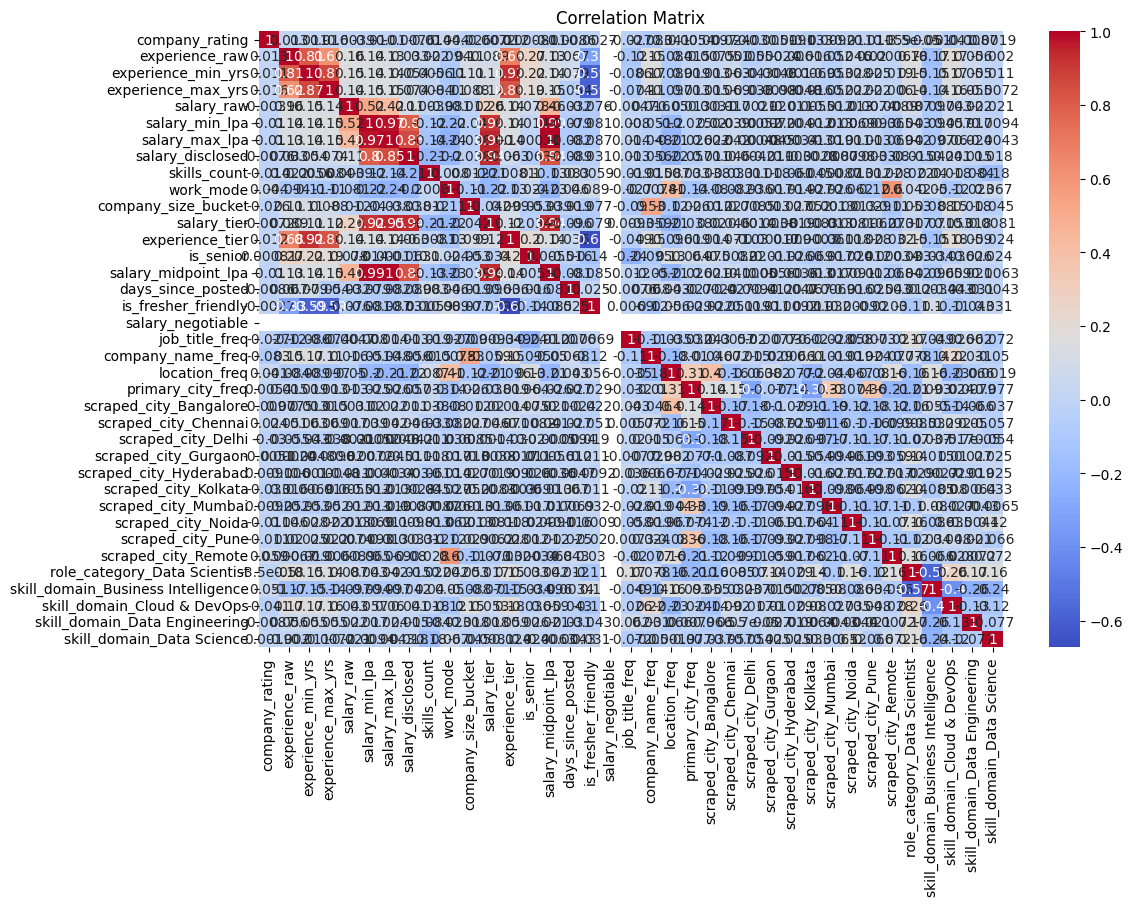

In [88]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True)
plt.title('Correlation Matrix')
plt.show()

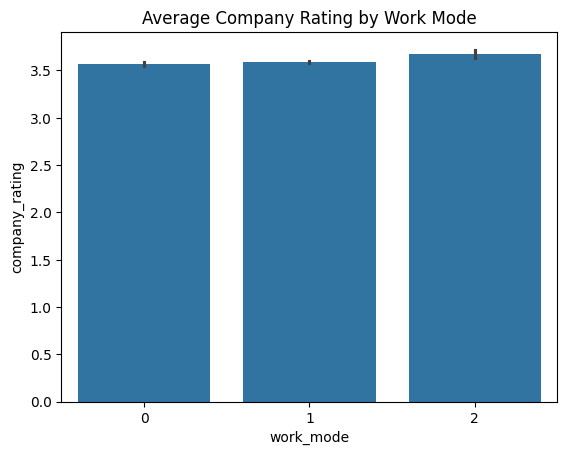

In [125]:
sns.barplot(
    data=df,
    x="work_mode",
    y="company_rating"
)

plt.title("Average Company Rating by Work Mode")
plt.show()

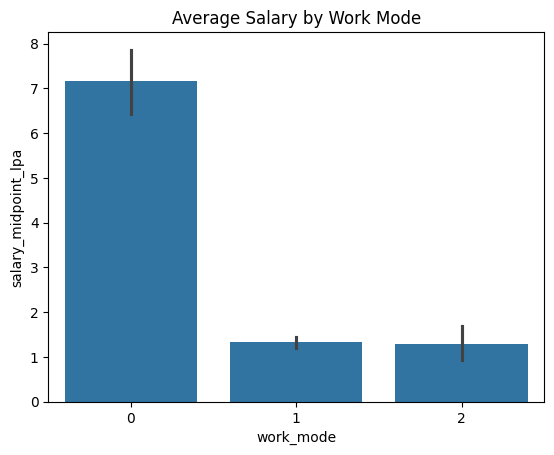

In [126]:
sns.barplot(data=df, x="work_mode", y="salary_midpoint_lpa")
plt.title("Average Salary by Work Mode")
plt.show()

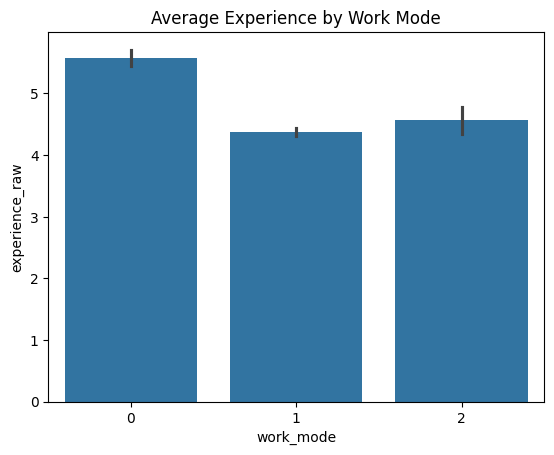

In [127]:
sns.barplot(data=df, x="work_mode", y="experience_raw")
plt.title("Average Experience by Work Mode")
plt.show()

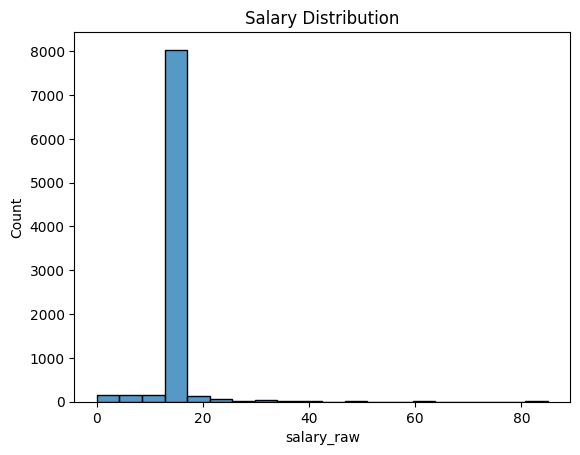

In [128]:
sns.histplot(data=df, x="salary_raw", bins=20)

plt.title("Salary Distribution")
plt.show()

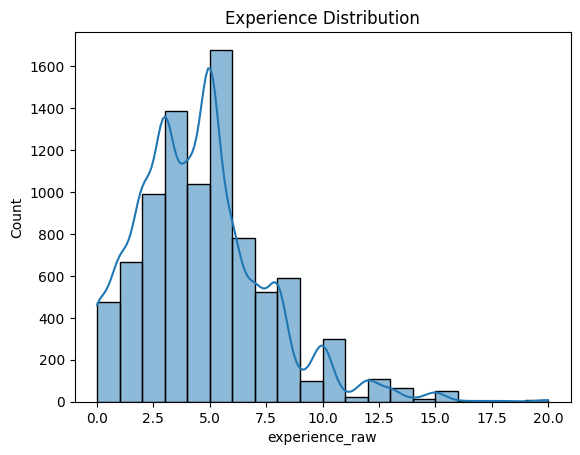

In [129]:
sns.histplot(data=df, x="experience_raw", bins=20, kde=True)

plt.title("Experience Distribution")
plt.show()

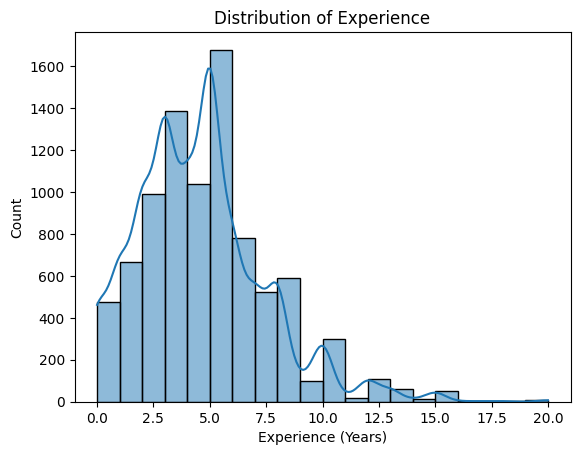

In [131]:
sns.histplot(df["experience_raw"], bins=20, kde=True)

plt.title("Distribution of Experience")
plt.xlabel("Experience (Years)")
plt.ylabel("Count")
plt.show()

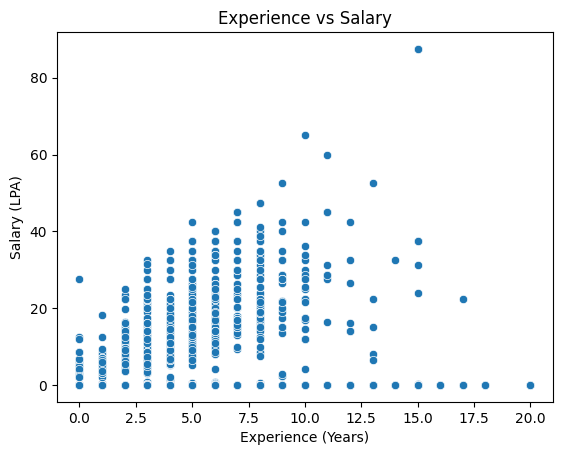

In [132]:
sns.scatterplot(
    data=df,
    x="experience_raw",
    y="salary_midpoint_lpa"
)

plt.title("Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary (LPA)")
plt.show()

In [89]:
from sklearn.linear_model import LogisticRegression

model_log = LogisticRegression(
    max_iter=500, class_weight="balanced", random_state=42
)
model_log.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)

In [90]:
pred_log = model_log.predict(X_test_scaled)
pred_prob = model_log.predict_proba(X_test_scaled)

In [91]:
y_pred_log = model_log.predict(X_test_scaled)

In [92]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

Accuracy: 0.8294485503126776
              precision    recall  f1-score   support

           0       0.45      0.92      0.60       209
           1       0.97      0.82      0.89      1404
           2       0.80      0.83      0.81       146

    accuracy                           0.83      1759
   macro avg       0.74      0.85      0.77      1759
weighted avg       0.89      0.83      0.85      1759

[[ 192   13    4]
 [ 231 1146   27]
 [   3   22  121]]


In [93]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, pred_log))
print(classification_report(y_test, pred_log))

Accuracy: 0.8294485503126776
              precision    recall  f1-score   support

           0       0.45      0.92      0.60       209
           1       0.97      0.82      0.89      1404
           2       0.80      0.83      0.81       146

    accuracy                           0.83      1759
   macro avg       0.74      0.85      0.77      1759
weighted avg       0.89      0.83      0.85      1759



In [94]:
from sklearn.model_selection import cross_val_score

# Balanced Accuracy
scores = cross_val_score(
    model_log,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="balanced_accuracy"
)

print("Balanced Accuracy:", scores)
print("Mean Balanced Accuracy:", scores.mean())

# F1 Score (Weighted)
scores = cross_val_score(
    model_log,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="f1_weighted"
)
print("Mean F1 (Weighted):", scores.mean())

# Recall (Weighted)
scores = cross_val_score(
    model_log,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="recall_weighted"
)
print("Mean Recall (Weighted):", scores.mean())

Balanced Accuracy: [0.87679707 0.88541903 0.85683784 0.84635386 0.87861121]
Mean Balanced Accuracy: 0.8688038025171239
Mean F1 (Weighted): 0.8512318223929605
Mean Recall (Weighted): 0.8327617146941577


In [95]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        random_state=42
    ))
])

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="balanced_accuracy"
)

print("Mean Balanced Accuracy:", scores.mean())

Mean Balanced Accuracy: 0.6433216034019784


In [96]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

model_dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [97]:
pred_dt = model_dt.predict(X_test)
pred_prob_dt = model_dt.predict_proba(X_test)

In [98]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, pred_dt))
print(classification_report(y_test, pred_dt))
print(confusion_matrix(y_test, pred_dt))

Accuracy: 0.9283683911313246
              precision    recall  f1-score   support

           0       0.73      0.74      0.74       209
           1       0.96      0.96      0.96      1404
           2       0.95      0.93      0.94       146

    accuracy                           0.93      1759
   macro avg       0.88      0.88      0.88      1759
weighted avg       0.93      0.93      0.93      1759

[[ 155   54    0]
 [  55 1342    7]
 [   1    9  136]]


In [99]:
from sklearn.model_selection import cross_val_score

# Balanced Accuracy
scores = cross_val_score(
    model_dt,
    X,
    y,
    cv=5,
    scoring="balanced_accuracy"
)
print("Mean Balanced Accuracy:", scores.mean())

# Weighted F1
scores = cross_val_score(
    model_dt,
    X,
    y,
    cv=5,
    scoring="f1_weighted"
)
print("Mean F1 (Weighted):", scores.mean())

# Weighted Recall
scores = cross_val_score(
    model_dt,
    X,
    y,
    cv=5,
    scoring="recall_weighted"
)
print("Mean Recall (Weighted):", scores.mean())

Mean Balanced Accuracy: 0.7083640450049151
Mean F1 (Weighted): 0.7344165631322164
Mean Recall (Weighted): 0.7193497313669146


In [100]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [101]:
pred_rf = model_rf.predict(X_test)

pred_prob_rf = model_rf.predict_proba(X_test)

In [102]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))
print(confusion_matrix(y_test, pred_rf))

Accuracy: 0.9340534394542354
              precision    recall  f1-score   support

           0       0.80      0.67      0.73       209
           1       0.94      0.98      0.96      1404
           2       1.00      0.91      0.95       146

    accuracy                           0.93      1759
   macro avg       0.91      0.85      0.88      1759
weighted avg       0.93      0.93      0.93      1759

[[ 140   69    0]
 [  34 1370    0]
 [   1   12  133]]


In [103]:
from sklearn.model_selection import cross_val_score

# Balanced Accuracy
scores = cross_val_score(
    model_rf,
    X,
    y,
    cv=5,
    scoring="balanced_accuracy"
)
print("Mean Balanced Accuracy:", scores.mean())

# Weighted F1
scores = cross_val_score(
    model_rf,
    X,
    y,
    cv=5,
    scoring="f1_weighted"
)
print("Mean F1 (Weighted):", scores.mean())

# Weighted Recall
scores = cross_val_score(
    model_rf,
    X,
    y,
    cv=5,
    scoring="recall_weighted"
)
print("Mean Recall (Weighted):", scores.mean())

Mean Balanced Accuracy: 0.7588799503554946
Mean F1 (Weighted): 0.8631780161406637
Mean Recall (Weighted): 0.8752113783752146


In [104]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [105]:
pred_xgb = model_xgb.predict(X_test)

pred_prob_xgb = model_xgb.predict_proba(X_test)

In [106]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, pred_xgb))
print(classification_report(y_test, pred_xgb))
print(confusion_matrix(y_test, pred_xgb))

Accuracy: 0.9494030699260944
              precision    recall  f1-score   support

           0       0.85      0.76      0.80       209
           1       0.96      0.98      0.97      1404
           2       1.00      0.92      0.96       146

    accuracy                           0.95      1759
   macro avg       0.94      0.89      0.91      1759
weighted avg       0.95      0.95      0.95      1759

[[ 159   50    0]
 [  27 1377    0]
 [   1   11  134]]


In [107]:
from sklearn.model_selection import cross_val_score

# Balanced Accuracy
scores = cross_val_score(
    model_xgb,
    X,
    y,
    cv=5,
    scoring="balanced_accuracy"
)
print("Mean Balanced Accuracy:", scores.mean())

# Weighted F1
scores = cross_val_score(
    model_xgb,
    X,
    y,
    cv=5,
    scoring="f1_weighted"
)
print("Mean F1 (Weighted):", scores.mean())

# Weighted Recall
scores = cross_val_score(
    model_xgb,
    X,
    y,
    cv=5,
    scoring="recall_weighted"
)
print("Mean Recall (Weighted):", scores.mean())

Mean Balanced Accuracy: 0.7599960191003233
Mean F1 (Weighted): 0.8392275621058424
Mean Recall (Weighted): 0.8383526683184999


In [108]:
from sklearn.ensemble import GradientBoostingClassifier

model_gbr = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model_gbr.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [109]:
pred_gbr = model_gbr.predict(X_test)

pred_prob_gbr = model_gbr.predict_proba(X_test)

In [110]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, pred_gbr))
print(classification_report(y_test, pred_gbr))
print(confusion_matrix(y_test, pred_gbr))

Accuracy: 0.939169982944855
              precision    recall  f1-score   support

           0       0.84      0.68      0.75       209
           1       0.95      0.98      0.96      1404
           2       0.99      0.91      0.95       146

    accuracy                           0.94      1759
   macro avg       0.93      0.86      0.89      1759
weighted avg       0.94      0.94      0.94      1759

[[ 142   67    0]
 [  26 1377    1]
 [   1   12  133]]


In [111]:
from sklearn.model_selection import cross_val_score

# Balanced Accuracy
scores = cross_val_score(
    model_gbr,
    X,
    y,
    cv=5,
    scoring="balanced_accuracy"
)
print("Mean Balanced Accuracy:", scores.mean())

# Weighted F1
scores = cross_val_score(
    model_gbr,
    X,
    y,
    cv=5,
    scoring="f1_weighted"
)
print("Mean F1 (Weighted):", scores.mean())

# Weighted Recall
scores = cross_val_score(
    model_gbr,
    X,
    y,
    cv=5,
    scoring="recall_weighted"
)
print("Mean Recall (Weighted):", scores.mean())

Mean Balanced Accuracy: 0.7509200707678949
Mean F1 (Weighted): 0.797191128329893
Mean Recall (Weighted): 0.7793035783466276


In [112]:
import joblib

joblib.dump(model_xgb, "work_mode_xgboost_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [113]:
import joblib

joblib.dump(le, "work_mode_label_encoder.pkl")

print("Label Encoder saved successfully!")

Label Encoder saved successfully!


In [114]:
import os

print(os.listdir())

['.config', 'work_mode_xgboost_model.pkl', 'work_mode_label_encoder.pkl', 'indian_tech_jobs_2026.csv', 'sample_data']


In [115]:
import os

print(os.path.exists("work_mode_xgboost_model.pkl"))
print(os.path.exists("work_mode_label_encoder.pkl"))

True
True


In [116]:
import joblib

joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [117]:
model = joblib.load("work_mode_xgboost_model.pkl")
label_encoder = joblib.load("work_mode_label_encoder.pkl")
feature_columns = joblib.load("feature_columns.pkl")

In [119]:
print(X.columns.tolist())

['company_rating', 'experience_raw', 'experience_min_yrs', 'experience_max_yrs', 'salary_raw', 'salary_min_lpa', 'salary_max_lpa', 'salary_disclosed', 'skills_count', 'company_size_bucket', 'salary_tier', 'experience_tier', 'is_senior', 'salary_midpoint_lpa', 'days_since_posted', 'is_fresher_friendly', 'salary_negotiable', 'job_title_freq', 'company_name_freq', 'location_freq', 'primary_city_freq', 'scraped_city_Bangalore', 'scraped_city_Chennai', 'scraped_city_Delhi', 'scraped_city_Gurgaon', 'scraped_city_Hyderabad', 'scraped_city_Kolkata', 'scraped_city_Mumbai', 'scraped_city_Noida', 'scraped_city_Pune', 'scraped_city_Remote', 'role_category_Data Scientist', 'skill_domain_Business Intelligence', 'skill_domain_Cloud & DevOps', 'skill_domain_Data Engineering', 'skill_domain_Data Science']


In [120]:
print("Number of training features:", len(X.columns))
print(X.columns.tolist())

Number of training features: 36
['company_rating', 'experience_raw', 'experience_min_yrs', 'experience_max_yrs', 'salary_raw', 'salary_min_lpa', 'salary_max_lpa', 'salary_disclosed', 'skills_count', 'company_size_bucket', 'salary_tier', 'experience_tier', 'is_senior', 'salary_midpoint_lpa', 'days_since_posted', 'is_fresher_friendly', 'salary_negotiable', 'job_title_freq', 'company_name_freq', 'location_freq', 'primary_city_freq', 'scraped_city_Bangalore', 'scraped_city_Chennai', 'scraped_city_Delhi', 'scraped_city_Gurgaon', 'scraped_city_Hyderabad', 'scraped_city_Kolkata', 'scraped_city_Mumbai', 'scraped_city_Noida', 'scraped_city_Pune', 'scraped_city_Remote', 'role_category_Data Scientist', 'skill_domain_Business Intelligence', 'skill_domain_Cloud & DevOps', 'skill_domain_Data Engineering', 'skill_domain_Data Science']


In [121]:
print("Number of model features:", len(model_xgb.feature_names_in_))
print(model_xgb.feature_names_in_)

Number of model features: 36
['company_rating' 'experience_raw' 'experience_min_yrs'
 'experience_max_yrs' 'salary_raw' 'salary_min_lpa' 'salary_max_lpa'
 'salary_disclosed' 'skills_count' 'company_size_bucket' 'salary_tier'
 'experience_tier' 'is_senior' 'salary_midpoint_lpa' 'days_since_posted'
 'is_fresher_friendly' 'salary_negotiable' 'job_title_freq'
 'company_name_freq' 'location_freq' 'primary_city_freq'
 'scraped_city_Bangalore' 'scraped_city_Chennai' 'scraped_city_Delhi'
 'scraped_city_Gurgaon' 'scraped_city_Hyderabad' 'scraped_city_Kolkata'
 'scraped_city_Mumbai' 'scraped_city_Noida' 'scraped_city_Pune'
 'scraped_city_Remote' 'role_category_Data Scientist'
 'skill_domain_Business Intelligence' 'skill_domain_Cloud & DevOps'
 'skill_domain_Data Engineering' 'skill_domain_Data Science']


In [122]:
print(model_xgb.get_booster().feature_names)

['company_rating', 'experience_raw', 'experience_min_yrs', 'experience_max_yrs', 'salary_raw', 'salary_min_lpa', 'salary_max_lpa', 'salary_disclosed', 'skills_count', 'company_size_bucket', 'salary_tier', 'experience_tier', 'is_senior', 'salary_midpoint_lpa', 'days_since_posted', 'is_fresher_friendly', 'salary_negotiable', 'job_title_freq', 'company_name_freq', 'location_freq', 'primary_city_freq', 'scraped_city_Bangalore', 'scraped_city_Chennai', 'scraped_city_Delhi', 'scraped_city_Gurgaon', 'scraped_city_Hyderabad', 'scraped_city_Kolkata', 'scraped_city_Mumbai', 'scraped_city_Noida', 'scraped_city_Pune', 'scraped_city_Remote', 'role_category_Data Scientist', 'skill_domain_Business Intelligence', 'skill_domain_Cloud & DevOps', 'skill_domain_Data Engineering', 'skill_domain_Data Science']


In [123]:
import joblib

joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("feature_columns.pkl saved successfully!")

feature_columns.pkl saved successfully!
